# lab no 9 (Decision Tree)

**Name: Adeena**

**Department: BSAI**

**RollNo: 2330-0001**

# Lab Activity

**1. Load the ice cream dataset. (/kaggle/input/temperature-and-ice-cream-sales/Ice Cream Sales - temperatures.csv**

**2. Prepare the dataset: Sperate the load dataset into dependent (Revenue) and independent (Temperatue) variables.**

**3. Split the dataset into train and test set of raito 80% and 20% respectiveily.**

**4. Import decision tree regressor from sklearn: from sklearn.tree import DecisionTreeRegressor**

**5. Prepare the decision tree classifier with default parameters.**

**6. Fit the model with reshaped train dataset.**

**7. Predict the model with reshaped test dataset.**

**8. Plot the decision tree regressor results**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor

# Load dataset
df = pd.read_csv("/kaggle/input/temperature-and-ice-cream-sales/Ice Cream Sales - temperatures.csv")

print(df.head())
      


   Temperature  Ice Cream Profits
0           39              13.17
1           40              11.88
2           41              18.82
3           42              18.65
4           43              17.02


In [2]:
# independent , dependent variable

X = df[['Temperature']].values     
y = df['Ice Cream Profits'].values            

In [3]:
# spllit dataset

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
# import , create  Decision Tree Regressor

model = DecisionTreeRegressor(random_state=42) 

In [5]:
# train model

model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [6]:
#  Predict using Test Data

y_pred = model.predict(X_test)

print("Predictions:", y_pred[:10])

Predictions: [54.015      29.12       24.342      66.46444444 34.54333333 53.64285714
 38.212      45.6925     50.2825     45.9175    ]


/tmp/ipykernel_13/1539172379.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)


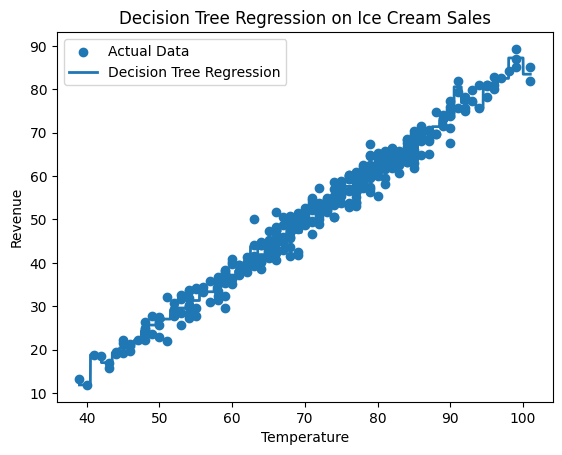

In [7]:
# Graph plot

plt.scatter(X, y, label="Actual Data") 

X_grid = np.arange(min(X), max(X), 0.01).reshape(-1, 1)

plt.plot(X_grid, model.predict(X_grid), linewidth=2, label="Decision Tree Regression")

plt.xlabel("Temperature")
plt.ylabel("Revenue")
plt.title("Decision Tree Regression on Ice Cream Sales")
plt.legend()
plt.show()


# lab Task 1 on Ice Cream dataset:

**4.2. Implement Decision Tree using following depth list: maxdepths =[2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50]**

**You apply Decision Tree classifier with different max of depth parameters in lab activity 4.2. You observe that model is lead to overfit. Try any other algorithm like Logistic Regression and SVM for the classification on this dataset and plot the graph to check weather these model are overfitting or underfitting**

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("/kaggle/input/temperature-and-ice-cream-sales/Ice Cream Sales - temperatures.csv")

print(df.head())

   Temperature  Ice Cream Profits
0           39              13.17
1           40              11.88
2           41              18.82
3           42              18.65
4           43              17.02


In [9]:
# 1 = High Revenue, 0 = Low Revenue

median_rev = df['Ice Cream Profits'].median()
df['Label'] = (df['Ice Cream Profits'] > median_rev).astype(int)

y = df['Label'].values

# train dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [10]:
# Decision Tree with multiple max depth

maxdepths = [2,3,4,5,6,7,8,9,10,15,20,25,30,35,40,45,50]

train_scores = []
test_scores = []

for d in maxdepths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)

    train_scores.append(model.score(X_train, y_train))
    test_scores.append(model.score(X_test, y_test))


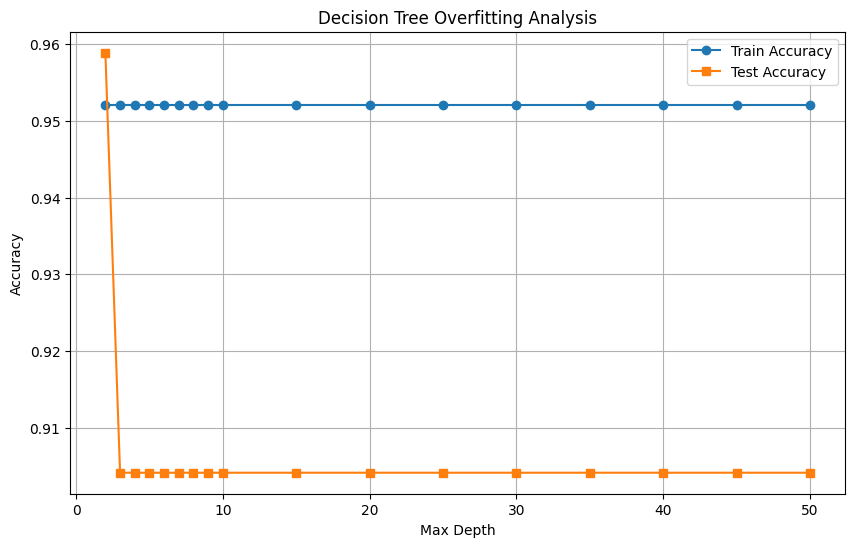

In [11]:
# Graph plot 

plt.figure(figsize=(10,6))
plt.plot(maxdepths, train_scores, marker='o', label='Train Accuracy')
plt.plot(maxdepths, test_scores, marker='s', label='Test Accuracy')

plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree Overfitting Analysis")
plt.legend()
plt.grid()
plt.show()

In [12]:
# logistic Regression 

log_model = LogisticRegression()
log_model.fit(X_train, y_train)

log_train = log_model.score(X_train, y_train)
log_test = log_model.score(X_test, y_test)

print("Logistic Regression Train Accuracy:", log_train)
print("Logistic Regression Test Accuracy:", log_test)

Logistic Regression Train Accuracy: 0.9486301369863014
Logistic Regression Test Accuracy: 0.958904109589041


In [13]:
# SVM (Linear Kernel)

svm_model = SVC(kernel="linear")
svm_model.fit(X_train, y_train)

svm_train = svm_model.score(X_train, y_train)
svm_test = svm_model.score(X_test, y_test)

print("SVM Train Accuracy:", svm_train)
print("SVM Test Accuracy:", svm_test)

SVM Train Accuracy: 0.9486301369863014
SVM Test Accuracy: 0.958904109589041


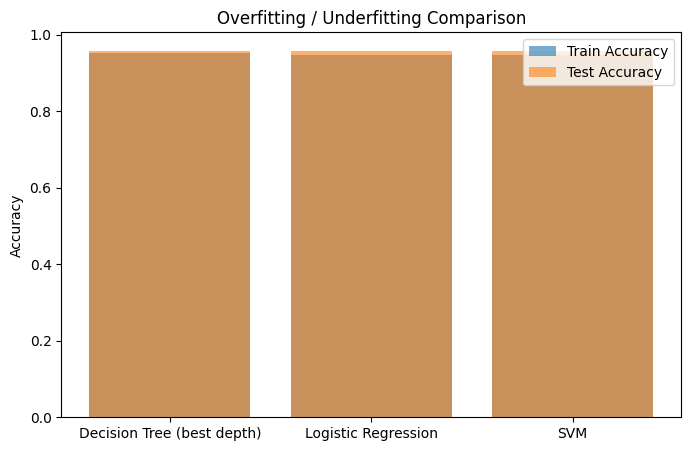

In [14]:
models = ['Decision Tree (best depth)', 'Logistic Regression', 'SVM']
train_acc = [max(train_scores), log_train, svm_train]
test_acc = [max(test_scores), log_test, svm_test]

plt.figure(figsize=(8,5))
plt.bar(models, train_acc, alpha=0.6, label="Train Accuracy")
plt.bar(models, test_acc, alpha=0.6, label="Test Accuracy")

plt.ylabel("Accuracy")
plt.title("Overfitting / Underfitting Comparison")
plt.legend()
plt.show()

# Lab Task 2 on Air Quality Rating.

In [15]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pickle

In [16]:
df = pd.read_csv('/kaggle/input/airline-quality-ratings/Airline Quality Ratings.csv')
df.head()

,ID,Gender,Age,Customer Type,Type of Travel,Class,Flight Distance,Departure Delay,Arrival Delay,Departure and Arrival Time Convenience,...,On-board Service,Seat Comfort,Leg Room Service,Cleanliness,Food and Drink,In-flight Service,In-flight Wifi Service,In-flight Entertainment,Baggage Handling,Satisfaction
0,1,Male,48,First-time,Business,Business,821,2,5.0,3,...,3,5,2,5,5,5,3,5,5,Neutral or Dissatisfied
1,2,Female,35,Returning,Business,Business,821,26,39.0,2,...,5,4,5,5,3,5,2,5,5,Satisfied
2,3,Male,41,Returning,Business,Business,853,0,0.0,4,...,3,5,3,5,5,3,4,3,3,Satisfied
3,4,Male,50,Returning,Business,Business,1905,0,0.0,2,...,5,5,5,4,4,5,2,5,5,Satisfied
4,5,Female,49,Returning,Business,Business,3470,0,1.0,3,...,3,4,4,5,4,3,3,3,3,Satisfied


In [17]:
target_column = "Satisfaction"

In [18]:
X = df.drop([target_column, "ID"], axis=1, errors='ignore')
y = df[target_column]

In [19]:
for col in X.select_dtypes(include=['int64', 'float64']).columns:
    X[col] = X[col].fillna(X[col].median())

In [20]:
for col in X.select_dtypes(include=['object']).columns:
    X[col] = X[col].fillna(X[col].mode()[0])

In [21]:
for col in X.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])

In [22]:
if y.dtype == 'object':
    y = LabelEncoder().fit_transform(y)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [24]:
with open("decision_tree_model.pkl", "wb") as file:
    pickle.dump(dt_model, file)

y_pred = dt_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

print("\n Model saved as 'decision_tree_model.pkl'")

Accuracy: 0.9462965814598091

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.95      0.95     14723
           1       0.93      0.94      0.94     11253

    accuracy                           0.95     25976
   macro avg       0.94      0.95      0.95     25976
weighted avg       0.95      0.95      0.95     25976


Confusion Matrix:
 [[13974   749]
 [  646 10607]]

 Model saved as 'decision_tree_model.pkl'


# Lab Task 3 On Car Price Prediction.


In [25]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score
import pickle

In [26]:
df = pd.read_csv('/kaggle/input/car-price-prediction/car_price_prediction_.csv')
df.head()

,Car ID,Brand,Year,Engine Size,Fuel Type,Transmission,Mileage,Condition,Price,Model
0,1,Tesla,2016,2.3,Petrol,Manual,114832,New,26613.92,Model X
1,2,BMW,2018,4.4,Electric,Manual,143190,Used,14679.61,5 Series
2,3,Audi,2013,4.5,Electric,Manual,181601,New,44402.61,A4
3,4,Tesla,2011,4.1,Diesel,Automatic,68682,New,86374.33,Model Y
4,5,Ford,2009,2.6,Diesel,Manual,223009,Like New,73577.10,Mustang


In [27]:
df.columns = df.columns.str.strip()

In [28]:
if 'car_ID' in df.columns:
    df = df.drop('car_ID', axis=1)
if 'CarName' in df.columns:
    df = df.drop('CarName', axis=1)

In [29]:
price_column = [col for col in df.columns if 'price' in col.lower()][0]
print("Target column identified:", price_column)

Target column identified: Price


In [30]:
categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)


In [31]:
X = df.drop(price_column, axis=1)
y = df[price_column]

In [32]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [33]:
dt_model = DecisionTreeRegressor(random_state=42)
dt_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [34]:
y_pred = dt_model.predict(X_test)

In [35]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R2 Score:", r2)


--- Model Evaluation ---
Mean Squared Error (MSE): 1460959993.998114
Root Mean Squared Error (RMSE): 38222.50638037901
R2 Score: -0.9285242790676209


In [36]:
model_file = 'decision_tree_car_model.pkl'
with open(model_file, 'wb') as f:
    pickle.dump({
        'model': dt_model,
        'features': X.columns.tolist()
    }, f)

print(f"\nModel and feature columns saved as '{model_file}'")


Model and feature columns saved as 'decision_tree_car_model.pkl'


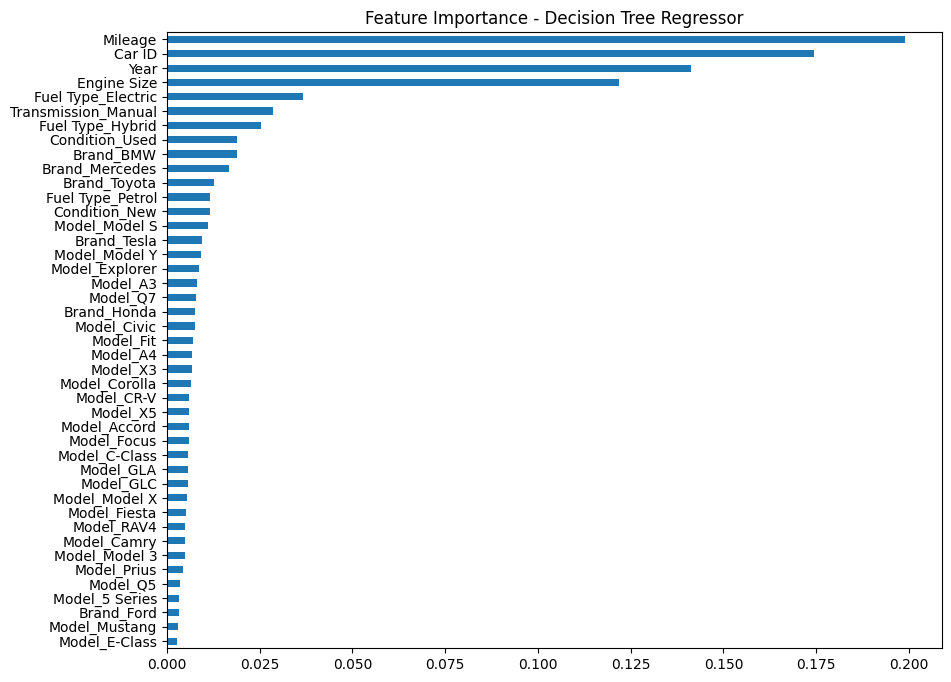

In [37]:
import matplotlib.pyplot as plt

feat_importances = pd.Series(dt_model.feature_importances_, index=X.columns)
feat_importances.sort_values().plot(kind='barh', figsize=(10,8))
plt.title("Feature Importance - Decision Tree Regressor")
plt.show()